In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")

from hubble_utils import *
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:


results_dir = Path("results/cosmo/mar9f_test")

rows = []

file_path = sorted(results_dir.iterdir())[0]

result = load_cosmo_results_hdf5(str(file_path))
print(f"Cosmo Result: ", result)
for model in ['FlatLambdaCDM', 'FlatwCDM', 'Flatw0waCDM']:
    N, z_i, z_f = result[model]["N"], result[model]['z_i'], result[model]['z_f']
    logZ = result[model]['logZ']
    print(f"For model {model}: {N=}, {z_i=}, {z_f=}")
    print("All results for the model: ", result[model].keys())
    print("\n")


Cosmo Result:  {'FlatLambdaCDM': {'H0': np.float64(73.47935765679885), 'H0_err': np.float64(0.9630383424994307), 'M0_agn': np.float64(-22.135943914065894), 'M0_agn_err': np.float64(0.06436044990708645), 'M0_sn': np.float64(-19.24286534830305), 'M0_sn_err': np.float64(0.028269807864148788), 'N': np.int64(2000), 'Om0': np.float64(0.33881552381199936), 'Om0_err': np.float64(0.01761183203554592), 'age': np.float64(12.408323254789732), 'age_err': np.float64(0.22729533894223916), 'alpha_agn': np.float64(4.639357067517125), 'alpha_agn_err': np.float64(0.29887435585600697), 'beta_agn': np.float64(-1.3557275383535128), 'beta_agn_err': np.float64(0.1265008189712601), 'logZ': np.float64(4156.610730056744), 'logZerr': np.float64(0.3167277202175046), 'log_f': np.float64(-0.10366745432357316), 'log_f_err': np.float64(0.03971428709985547), 'z_f': np.float64(1.5), 'z_i': np.float64(0.44)}, 'Flatw0waCDM': {'H0': np.float64(73.03550119706634), 'H0_err': np.float64(1.0603721675188567), 'M0_agn': np.float

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("results/cosmo/mar9f_test")

rows = []

for file_path in sorted(results_dir.iterdir()):
    if not file_path.is_file():
        continue

    result = load_cosmo_results_hdf5(str(file_path))

    for model in ["FlatLambdaCDM", "FlatwCDM", "Flatw0waCDM"]:
        rows.append({
            "cosmo_model": model,
            "logZ": result[model]["logZ"],
            "logZerr": result[model]["logZerr"],
            "N": result[model]["N"],
            "z_f": result[model]["z_f"],
        })

df = pd.DataFrame(rows)
df = df.sort_values(["N", "z_f", "cosmo_model"]).reset_index(drop=True)

df.head()

,cosmo_model,logZ,logZerr,N,z_f
0,FlatLambdaCDM,2231.197033,0.298148,500,1.0
1,Flatw0waCDM,2226.711417,0.321059,500,1.0
2,FlatwCDM,2229.005148,0.310293,500,1.0
3,FlatLambdaCDM,2380.120154,0.296172,500,1.5
4,Flatw0waCDM,2375.063570,0.324124,500,1.5


In [4]:
import numpy as np

def odds_sigmas_from_logZ(logZ_a, logZ_b, logZ_a_err, logZ_b_err):
    """
    Compute:
        delta     = logZ_a - logZ_b
        delta_err = sqrt(logZ_a_err^2 + logZ_b_err^2)   [independent errors]
        sigma     = sqrt(2 * |delta|)
        sigma_err = delta_err / sqrt(2 * |delta|)

    Returns
    -------
    delta, delta_err, sigma, sigma_err
    """
    logZ_a = np.asarray(logZ_a, dtype=float)
    logZ_b = np.asarray(logZ_b, dtype=float)
    logZ_a_err = np.asarray(logZ_a_err, dtype=float)
    logZ_b_err = np.asarray(logZ_b_err, dtype=float)

    delta = logZ_a - logZ_b
    delta_err = np.sqrt(logZ_a_err**2 + logZ_b_err**2)

    abs_delta = np.abs(delta)
    sigma = np.sqrt(2.0 * abs_delta)

    sigma_err = np.full_like(sigma, np.inf, dtype=float)
    mask = abs_delta > 0
    sigma_err[mask] = delta_err[mask] / np.sqrt(2.0 * abs_delta[mask])

    return delta, delta_err, sigma, sigma_err

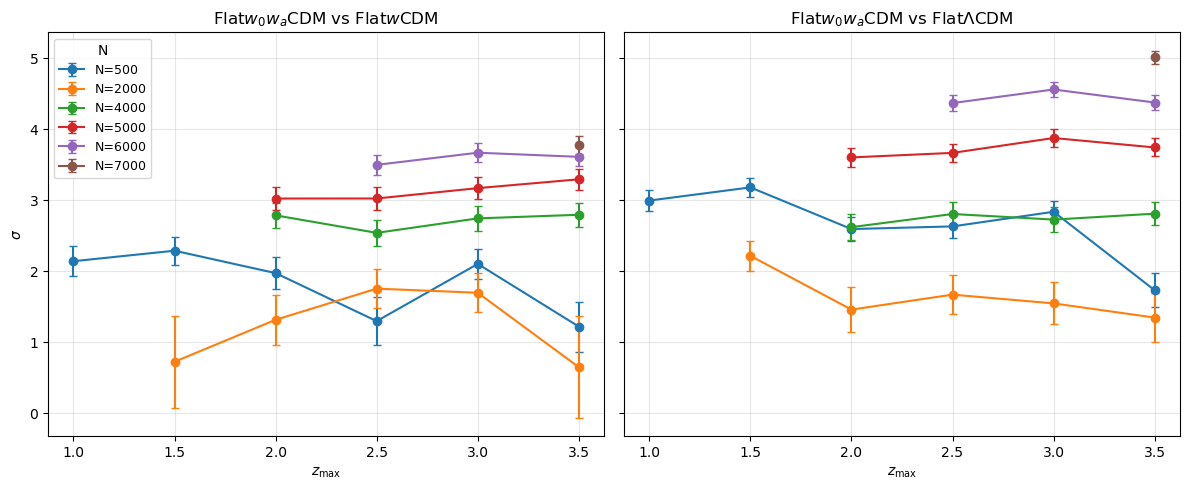

In [5]:
# Pivot so each row is one (N, z_f), with columns for logZ and logZerr of each cosmology
df_logZ = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZ")
df_logZerr = df.pivot(index=["N", "z_f"], columns="cosmo_model", values="logZerr")

dfw = pd.concat(
    {
        "logZ": df_logZ,
        "logZerr": df_logZerr,
    },
    axis=1,
).reset_index()

# Compute delta, delta_err, sigma, sigma_err for Flatw0waCDM vs FlatwCDM
res_w = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatwCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatwCDM")],
)

dfw["delta_w0wa_minus_w"] = res_w[0]
dfw["deltaerr_w0wa_minus_w"] = res_w[1]
dfw["sigma_w0wa_vs_w"] = res_w[2]
dfw["sigmaerr_w0wa_vs_w"] = res_w[3]

# Compute delta, delta_err, sigma, sigma_err for Flatw0waCDM vs FlatLambdaCDM
res_lcdm = odds_sigmas_from_logZ(
    dfw[("logZ", "Flatw0waCDM")],
    dfw[("logZ", "FlatLambdaCDM")],
    dfw[("logZerr", "Flatw0waCDM")],
    dfw[("logZerr", "FlatLambdaCDM")],
)

dfw["delta_w0wa_minus_lcdm"] = res_lcdm[0]
dfw["deltaerr_w0wa_minus_lcdm"] = res_lcdm[1]
dfw["sigma_w0wa_vs_lcdm"] = res_lcdm[2]
dfw["sigmaerr_w0wa_vs_lcdm"] = res_lcdm[3]

dfw = dfw.sort_values(["N", "z_f"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for N in sorted(dfw["N"].unique()):
    sub = dfw[dfw["N"] == N].sort_values("z_f")

    axes[0].errorbar(
        sub["z_f"],
        sub["sigma_w0wa_vs_w"],
        yerr=sub["sigmaerr_w0wa_vs_w"],
        marker="o",
        capsize=3,
        label=f"N={N}",
    )

    axes[1].errorbar(
        sub["z_f"],
        sub["sigma_w0wa_vs_lcdm"],
        yerr=sub["sigmaerr_w0wa_vs_lcdm"],
        marker="o",
        capsize=3,
        label=f"N={N}",
    )

axes[0].set_title(r"Flat$w_0w_a$CDM vs Flat$w$CDM")
axes[1].set_title(r"Flat$w_0w_a$CDM vs Flat$\Lambda$CDM")

axes[0].set_xlabel(r"$z_{\max}$")
axes[1].set_xlabel(r"$z_{\max}$")
axes[0].set_ylabel(r"$\sigma$")

axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

axes[0].legend(title="N", fontsize=9)

plt.tight_layout()
plt.show()